In [1]:
import os, glob, zipfile, random, cv2, numpy as np, pandas as pd, matplotlib.pyplot as plt, tensorflow as tf
from IPython.display import display
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
s=42
random.seed(s)
np.random.seed(s)
tf.random.set_seed(s)
print(tf.config.list_physical_devices('GPU'))


2026-04-15 08:45:01.809587: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776242701.999789      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776242702.049760      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776242702.461597      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776242702.461645      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776242702.461649      55 computation_placer.cc:177] computation placer alr

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
def fd(b):
    z=[]
    for x in b:
        if os.path.exists(x):
            for q in glob.glob(os.path.join(x,'**','fake'),recursive=True):
                r=os.path.dirname(q)
                if os.path.isdir(os.path.join(r,'real')):
                    z.append(r)
    return sorted(list(set(z)),key=len)

def fp():
    b=['/kaggle/input','/mnt/data','.']
    d=fd(b)
    if d:
        return d[0]
    z=[]
    for x in b:
        if os.path.exists(x):
            z+=glob.glob(os.path.join(x,'**','*.zip'),recursive=True)
    if not z:
        raise FileNotFoundError('data not found')
    zp=sorted(z)[0]
    od='/kaggle/working/ffx' if os.path.exists('/kaggle/working') else '/mnt/data/ffx'
    os.makedirs(od,exist_ok=True)
    if not fd([od]):
        with zipfile.ZipFile(zp) as f:
            f.extractall(od)
    d=fd([od])
    if not d:
        raise FileNotFoundError('fake/real folders not found')
    return d[0]

dp=fp()
ff=sorted(glob.glob(os.path.join(dp,'fake','*.mp4')))
rr=sorted(glob.glob(os.path.join(dp,'real','*.mp4')))
p=ff+rr
y=np.array([1]*len(ff)+[0]*len(rr),dtype=np.float32)

def gi(x):
    c=cv2.VideoCapture(x)
    n=int(c.get(cv2.CAP_PROP_FRAME_COUNT))
    w=int(c.get(cv2.CAP_PROP_FRAME_WIDTH))
    h=int(c.get(cv2.CAP_PROP_FRAME_HEIGHT))
    f=float(c.get(cv2.CAP_PROP_FPS))
    c.release()
    return [os.path.basename(x),n,w,h,f]

print(dp)
display(pd.DataFrame([['fake',len(ff)],['real',len(rr)],['all',len(p)]],columns=['c','n']))
display(pd.DataFrame([gi(ff[0]),gi(rr[0])],columns=['f','n','w','h','fps']))


/kaggle/input/datasets/rejoankawaho/deepfake/faceforensics


,c,n
0,fake,50
1,real,50
2,all,100


,f,n,w,h,fps
0,000_003.mp4,303,640,480,25.0
1,000.mp4,396,640,480,25.0


(100, 12, 112, 112, 3)


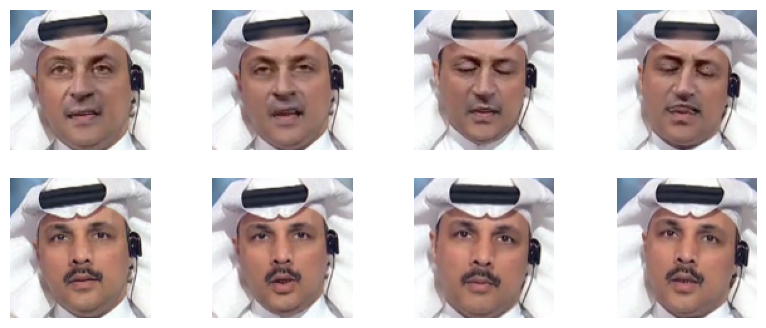

In [3]:
fc=cv2.CascadeClassifier(cv2.data.haarcascades+'haarcascade_frontalface_default.xml')

def cf(f,s1=112):
    g=cv2.cvtColor(f,cv2.COLOR_BGR2GRAY)
    b=fc.detectMultiScale(g,1.1,4)
    if len(b)>0:
        x,y,w,h=sorted(b,key=lambda z:z[2]*z[3],reverse=True)[0]
        m=int(0.15*max(w,h))
        x=max(0,x-m)
        y=max(0,y-m)
        w=min(f.shape[1]-x,w+2*m)
        h=min(f.shape[0]-y,h+2*m)
        f=f[y:y+h,x:x+w]
    f=cv2.cvtColor(f,cv2.COLOR_BGR2RGB)
    return cv2.resize(f,(s1,s1)).astype(np.float32)

def rv(x,t=12,s1=112):
    c=cv2.VideoCapture(x)
    n=int(c.get(cv2.CAP_PROP_FRAME_COUNT))
    if n<=0:
        n=t
    ix=np.linspace(0,max(n-1,0),t,dtype=int)
    z=[]
    for k in ix:
        c.set(cv2.CAP_PROP_POS_FRAMES,int(k))
        ok,f=c.read()
        if ok:
            z.append(cf(f,s1))
    c.release()
    while len(z)<t:
        if z:
            z.append(z[-1].copy())
        else:
            z.append(np.zeros((s1,s1,3),dtype=np.float32))
    return np.array(z,dtype=np.float32)

xv=[]
for q in p:
    xv.append(rv(q))
xv=np.array(xv,dtype=np.float32)
print(xv.shape)
plt.figure(figsize=(10,4))
for i in range(4):
    plt.subplot(2,4,i+1)
    plt.imshow((xv[0,i]/255.0).clip(0,1))
    plt.axis('off')
for i in range(4):
    plt.subplot(2,4,i+5)
    plt.imshow((xv[len(ff),i]/255.0).clip(0,1))
    plt.axis('off')
plt.show()


In [4]:
def gb():
    try:
        from tensorflow.keras.applications.efficientnet import EfficientNetB0, preprocess_input
        b=EfficientNetB0(include_top=False,weights='imagenet',input_shape=xv.shape[2:],pooling='avg')
        p1=preprocess_input
        w='efficientnetb0_imagenet'
    except Exception:
        try:
            from tensorflow.keras.applications.mobilenet_v2 import MobileNetV2, preprocess_input
            b=MobileNetV2(include_top=False,weights='imagenet',input_shape=xv.shape[2:],pooling='avg')
            p1=preprocess_input
            w='mobilenetv2_imagenet'
        except Exception:
            from tensorflow.keras.applications.mobilenet_v2 import MobileNetV2, preprocess_input
            b=MobileNetV2(include_top=False,weights=None,input_shape=xv.shape[2:],pooling='avg')
            p1=preprocess_input
            w='mobilenetv2_none'
    b.trainable=False
    return b,p1,w

be,pp,wt=gb()
print(wt)
xx=pp(xv.copy()).astype(np.float32)
ft=be.predict(xx.reshape(-1,*xv.shape[2:]),batch_size=32,verbose=1).astype(np.float32).reshape(len(xv),xv.shape[1],-1)
print(ft.shape)


I0000 00:00:1776243096.945537      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15253 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
efficientnetb0_imagenet


I0000 00:00:1776243102.322884     845 service.cc:152] XLA service 0x7d2e6c003f10 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1776243102.322944     845 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1776243103.220774     845 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1776243109.182946     845 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


38/38 ━━━━━━━━━━━━━━━━━━━━ 18s 239ms/step
(100, 12, 1280)


In [5]:
ii=np.arange(len(y))
it,iu,yt,yu=train_test_split(ii,y,test_size=0.2,random_state=s,stratify=y)
iv,ie,yv,ye=train_test_split(iu,yu,test_size=0.5,random_state=s,stratify=yu)
def zn(x,i):
    m=x[i].reshape(-1,x.shape[-1]).mean(0,keepdims=True).astype(np.float32)
    d=x[i].reshape(-1,x.shape[-1]).std(0,keepdims=True).astype(np.float32)+1e-6
    return ((x-m)/d).astype(np.float32),m,d
fz,fm,fd=zn(ft,it)
fa=fz.mean(1).astype(np.float32)
print(len(it),len(iv),len(ie),fz.shape,fa.shape)


80 10 10 (100, 12, 1280) (100, 1280)


In [6]:
def ba(d):
    i=tf.keras.Input(shape=(d,))
    x=tf.keras.layers.Dense(512,activation='relu')(i)
    x=tf.keras.layers.Dropout(0.4)(x)
    x=tf.keras.layers.Dense(128,activation='relu')(x)
    x=tf.keras.layers.Dropout(0.3)(x)
    o=tf.keras.layers.Dense(1,activation='sigmoid')(x)
    m=tf.keras.Model(i,o)
    m.compile(optimizer=tf.keras.optimizers.Adam(3e-4),loss='binary_crossentropy',metrics=['accuracy'])
    return m

def bc(t,d):
    i=tf.keras.Input(shape=(t,d))
    x=tf.keras.layers.Conv1D(256,3,padding='same',activation='relu')(i)
    x=tf.keras.layers.BatchNormalization()(x)
    x=tf.keras.layers.MaxPool1D()(x)
    x=tf.keras.layers.Conv1D(128,3,padding='same',activation='relu')(x)
    x=tf.keras.layers.GlobalMaxPool1D()(x)
    x=tf.keras.layers.Dropout(0.3)(x)
    x=tf.keras.layers.Dense(64,activation='relu')(x)
    o=tf.keras.layers.Dense(1,activation='sigmoid')(x)
    m=tf.keras.Model(i,o)
    m.compile(optimizer=tf.keras.optimizers.Adam(3e-4),loss='binary_crossentropy',metrics=['accuracy'])
    return m

def br(t,d):
    i=tf.keras.Input(shape=(t,d))
    x=tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(128))(i)
    x=tf.keras.layers.Dropout(0.3)(x)
    x=tf.keras.layers.Dense(64,activation='relu')(x)
    o=tf.keras.layers.Dense(1,activation='sigmoid')(x)
    m=tf.keras.Model(i,o)
    m.compile(optimizer=tf.keras.optimizers.Adam(3e-4),loss='binary_crossentropy',metrics=['accuracy'])
    return m

def bcr(t,d):
    i=tf.keras.Input(shape=(t,d))
    x=tf.keras.layers.Conv1D(256,3,padding='same',activation='relu')(i)
    x=tf.keras.layers.BatchNormalization()(x)
    x=tf.keras.layers.MaxPool1D()(x)
    x=tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(128))(x)
    x=tf.keras.layers.Dropout(0.3)(x)
    x=tf.keras.layers.Dense(64,activation='relu')(x)
    o=tf.keras.layers.Dense(1,activation='sigmoid')(x)
    m=tf.keras.Model(i,o)
    m.compile(optimizer=tf.keras.optimizers.Adam(3e-4),loss='binary_crossentropy',metrics=['accuracy'])
    return m

def bt(t,d):
    i=tf.keras.Input(shape=(t,d))
    x=tf.keras.layers.LayerNormalization()(i)
    a=tf.keras.layers.MultiHeadAttention(num_heads=4,key_dim=64,dropout=0.2)(x,x)
    x=tf.keras.layers.Add()([x,a])
    y1=tf.keras.layers.LayerNormalization()(x)
    y1=tf.keras.layers.Dense(256,activation='relu')(y1)
    y1=tf.keras.layers.Dropout(0.3)(y1)
    y1=tf.keras.layers.Dense(d)(y1)
    x=tf.keras.layers.Add()([x,y1])
    x=tf.keras.layers.GlobalAveragePooling1D()(x)
    x=tf.keras.layers.Dense(128,activation='relu')(x)
    x=tf.keras.layers.Dropout(0.3)(x)
    o=tf.keras.layers.Dense(1,activation='sigmoid')(x)
    m=tf.keras.Model(i,o)
    m.compile(optimizer=tf.keras.optimizers.Adam(3e-4),loss='binary_crossentropy',metrics=['accuracy'])
    return m

def gbm(k):
    if k=='ann':
        return ba(fa.shape[1]),fa,20,16
    if k=='cnn':
        return bc(fz.shape[1],fz.shape[2]),fz,20,16
    if k=='rnn':
        return br(fz.shape[1],fz.shape[2]),fz,22,16
    if k=='cnn_rnn':
        return bcr(fz.shape[1],fz.shape[2]),fz,22,16
    return bt(fz.shape[1],fz.shape[2]),fz,24,16


In [7]:
ms={}
hs={}
rs=[]
ppb={}
for k in ['ann','cnn','rnn','cnn_rnn','transformer']:
    m,x,ep,bs=gbm(k)
    fp1=f'{k}_best.keras'
    cb=[tf.keras.callbacks.ModelCheckpoint(fp1,monitor='val_accuracy',mode='max',save_best_only=True,verbose=1)]
    h=m.fit(x[it],y[it],validation_data=(x[iv],y[iv]),epochs=ep,batch_size=bs,verbose=1,callbacks=cb)
    m=tf.keras.models.load_model(fp1)
    tr=float(m.evaluate(x[it],y[it],verbose=0)[1])
    va=float(m.evaluate(x[iv],y[iv],verbose=0)[1])
    te=float(m.evaluate(x[ie],y[ie],verbose=0)[1])
    pr=m.predict(x[ie],batch_size=bs,verbose=0).ravel().astype(np.float32)
    ms[k]=m
    hs[k]=pd.DataFrame(h.history)
    ppb[k]=pr
    rs.append([k,tr,va,te,float(np.max(h.history['val_accuracy'])),int(np.argmax(h.history['val_accuracy'])+1)])
rf=pd.DataFrame(rs,columns=['m','tr','va','te','best_va','best_ep']).sort_values('te',ascending=False).reset_index(drop=True)
display(rf)
rf.to_csv('model_scores_full.csv',index=False)


Epoch 1/20
1/5 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - accuracy: 0.6250 - loss: 0.9629
Epoch 1: val_accuracy improved from -inf to 0.30000, saving model to ann_best.keras
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 129ms/step - accuracy: 0.5606 - loss: 0.9895 - val_accuracy: 0.3000 - val_loss: 0.8742
Epoch 2/20
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.7500 - loss: 0.5281
Epoch 2: val_accuracy improved from 0.30000 to 0.40000, saving model to ann_best.keras
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.6948 - loss: 0.5872 - val_accuracy: 0.4000 - val_loss: 0.9571
Epoch 3/20
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.8750 - loss: 0.4919
Epoch 3: val_accuracy did not improve from 0.40000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7227 - loss: 0.5890 - val_accuracy: 0.4000 - val_loss: 1.1039
Epoch 4/20
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.8125 - loss: 0.4490
Epoch 4: val_accuracy did not improve from 0.40000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.75

,m,tr,va,te,best_va,best_ep
0,cnn,0.7125,0.3,0.3,0.3,1
1,transformer,0.6250,0.4,0.3,0.4,1
2,cnn_rnn,0.7000,0.2,0.2,0.2,1
3,ann,0.7000,0.4,0.1,0.4,2
4,rnn,0.7250,0.3,0.1,0.3,1


ann


,accuracy,loss,val_accuracy,val_loss
0,0.5125,1.061156,0.3,0.874197
1,0.6000,0.678376,0.4,0.957105
2,0.6500,0.659398,0.4,1.103913
3,0.7375,0.501097,0.2,1.243034
4,0.7750,0.453027,0.1,1.397740
5,0.7875,0.463323,0.1,1.548424
6,0.8250,0.369014,0.1,1.700648
7,0.8125,0.413380,0.1,1.858497
8,0.7875,0.400955,0.2,1.958290
9,0.8750,0.346066,0.2,2.040733


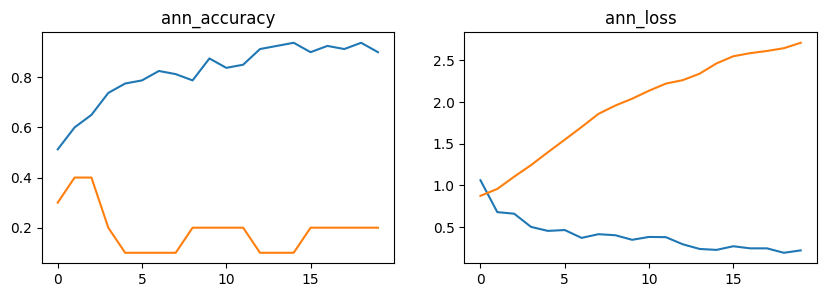

cnn


,accuracy,loss,val_accuracy,val_loss
0,0.4375,0.999332,0.3,1.126258
1,0.7750,0.420822,0.3,1.393877
2,0.9000,0.246248,0.2,1.479731
3,0.9375,0.191714,0.2,1.566949
4,0.9500,0.159032,0.1,1.712184
5,0.9750,0.127050,0.1,1.834086
6,0.9875,0.079501,0.1,1.931979
7,1.0000,0.052432,0.1,2.039910
8,1.0000,0.049683,0.1,2.157900
9,1.0000,0.034274,0.1,2.261700


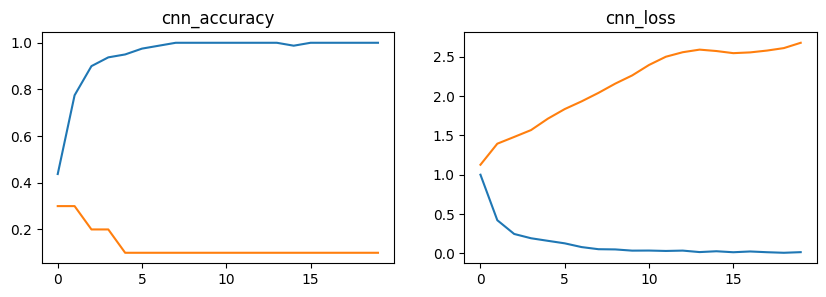

rnn


,accuracy,loss,val_accuracy,val_loss
0,0.3875,0.809315,0.3,0.889769
1,0.7250,0.539056,0.2,1.032675
2,0.9125,0.413866,0.1,1.149849
3,0.9375,0.356338,0.1,1.276204
4,0.9750,0.289402,0.1,1.399999
5,0.9750,0.239337,0.1,1.517835
6,0.9875,0.198827,0.1,1.627740
7,1.0000,0.161406,0.1,1.742018
8,1.0000,0.130982,0.1,1.846967
9,1.0000,0.105759,0.1,1.943908


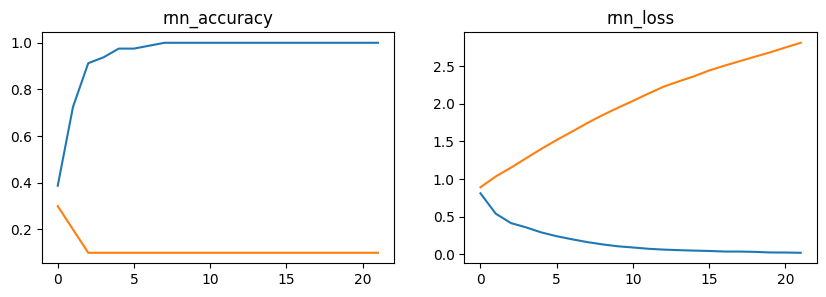

cnn_rnn


,accuracy,loss,val_accuracy,val_loss
0,0.4500,0.770182,0.2,0.944578
1,0.8625,0.493032,0.2,1.083382
2,0.9500,0.396196,0.1,1.216119
3,0.9875,0.306649,0.1,1.344752
4,1.0000,0.242189,0.1,1.476498
5,1.0000,0.193820,0.1,1.607227
6,1.0000,0.152368,0.1,1.755933
7,1.0000,0.112170,0.2,1.902726
8,1.0000,0.087661,0.2,2.042483
9,1.0000,0.071906,0.2,2.177616


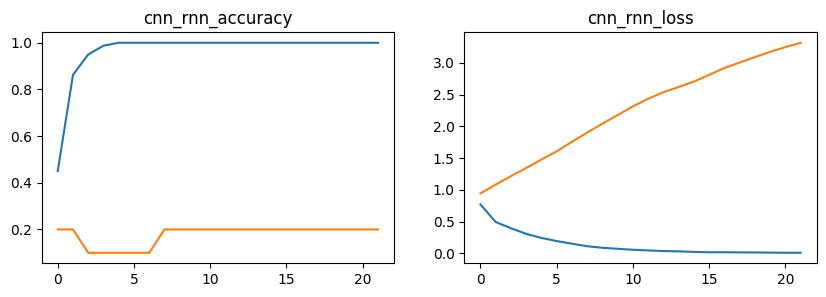

transformer


,accuracy,loss,val_accuracy,val_loss
0,0.4000,1.130881,0.4,1.352886
1,0.6000,0.637243,0.2,1.515887
2,0.8250,0.411873,0.2,1.862193
3,0.8000,0.420964,0.2,2.051392
4,0.8625,0.342574,0.1,2.270800
5,0.9250,0.264835,0.1,2.410403
6,0.9125,0.250699,0.1,2.574417
7,0.9500,0.211413,0.1,2.933052
8,1.0000,0.100669,0.2,3.213030
9,0.9750,0.112165,0.1,3.181612


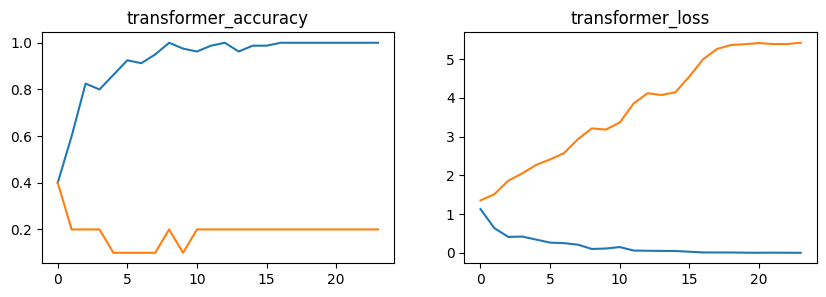

In [8]:
for k,v in hs.items():
    print(k)
    display(v)
    plt.figure(figsize=(10,3))
    plt.subplot(1,2,1)
    plt.plot(v['accuracy'])
    plt.plot(v['val_accuracy'])
    plt.title(k+'_accuracy')
    plt.subplot(1,2,2)
    plt.plot(v['loss'])
    plt.plot(v['val_loss'])
    plt.title(k+'_loss')
    plt.show()


In [9]:
rt=[]
for k,p1 in ppb.items():
    y1=(p1>=0.5).astype(np.float32)
    cm=confusion_matrix(ye,y1)
    print(k)
    print(cm)
    print(classification_report(ye,y1,digits=4))
    rt.append([k,accuracy_score(ye,y1),cm[0,0],cm[0,1],cm[1,0],cm[1,1]])
pe=np.mean(np.column_stack([ppb[k] for k in ['ann','cnn','rnn','cnn_rnn','transformer']]),axis=1)
ye1=(pe>=0.5).astype(np.float32)
cm=confusion_matrix(ye,ye1)
print('ensemble')
print(cm)
print(classification_report(ye,ye1,digits=4))
rt.append(['ensemble',accuracy_score(ye,ye1),cm[0,0],cm[0,1],cm[1,0],cm[1,1]])
re=pd.DataFrame(rt,columns=['m','te','tn','fp','fn','tp']).sort_values('te',ascending=False).reset_index(drop=True)
display(re)
re.to_csv('evaluation_scores_full.csv',index=False)


ann
[[0 5]
 [4 1]]
              precision    recall  f1-score   support

         0.0     0.0000    0.0000    0.0000         5
         1.0     0.1667    0.2000    0.1818         5

    accuracy                         0.1000        10
   macro avg     0.0833    0.1000    0.0909        10
weighted avg     0.0833    0.1000    0.0909        10

cnn
[[1 4]
 [3 2]]
              precision    recall  f1-score   support

         0.0     0.2500    0.2000    0.2222         5
         1.0     0.3333    0.4000    0.3636         5

    accuracy                         0.3000        10
   macro avg     0.2917    0.3000    0.2929        10
weighted avg     0.2917    0.3000    0.2929        10

rnn
[[0 5]
 [4 1]]
              precision    recall  f1-score   support

         0.0     0.0000    0.0000    0.0000         5
         1.0     0.1667    0.2000    0.1818         5

    accuracy                         0.1000        10
   macro avg     0.0833    0.1000    0.0909        10
weighted avg     

,m,te,tn,fp,fn,tp
0,cnn,0.3,1,4,3,2
1,transformer,0.3,1,4,3,2
2,cnn_rnn,0.2,1,4,4,1
3,ann,0.1,0,5,4,1
4,rnn,0.1,0,5,4,1
5,ensemble,0.0,0,5,5,0


In [10]:
tb=pd.DataFrame({'file':[os.path.basename(p[i]) for i in ie],'y':ye.astype(int)})
for k,v in ppb.items():
    tb[k+'_p']=v
    tb[k+'_pd']=(v>=0.5).astype(int)
tb['ensemble_p']=pe
tb['ensemble_pd']=(pe>=0.5).astype(int)
display(tb)
tb.to_csv('test_video_predictions.csv',index=False)


,file,y,ann_p,ann_pd,cnn_p,cnn_pd,rnn_p,rnn_pd,cnn_rnn_p,cnn_rnn_pd,transformer_p,transformer_pd,ensemble_p,ensemble_pd
0,028.mp4,0,0.560682,1,0.441174,0,0.707035,1,0.619960,1,0.467136,0,0.559197,1
1,034_590.mp4,1,0.415311,0,0.388707,0,0.335719,0,0.527726,1,0.569534,1,0.447399,0
2,019_018.mp4,1,0.449535,0,0.706232,1,0.643702,1,0.378221,0,0.309865,0,0.497511,0
3,022.mp4,0,0.918195,1,0.565277,1,0.586698,1,0.666221,1,0.552404,1,0.657759,1
4,043_110.mp4,1,0.509968,1,0.514130,1,0.423876,0,0.454822,0,0.462687,0,0.473097,0
5,020.mp4,0,0.800582,1,0.636732,1,0.549471,1,0.482578,0,0.890821,1,0.672037,1
6,018.mp4,0,0.584099,1,0.877633,1,0.770584,1,0.506316,1,0.827342,1,0.713195,1
7,049.mp4,0,0.848090,1,0.723093,1,0.682538,1,0.550846,1,0.966641,1,0.754242,1
8,025_067.mp4,1,0.383034,0,0.228259,0,0.497445,0,0.435252,0,0.111233,0,0.331045,0
9,013_883.mp4,1,0.492372,0,0.322971,0,0.443314,0,0.432355,0,0.597748,1,0.457752,0


In [12]:
bf=re.iloc[0]['m']
print(bf)
def pv(q):
    a=rv(q,xv.shape[1],xv.shape[2])
    b=pp(a.copy()).astype(np.float32)
    f=be.predict(b,batch_size=b.shape[0],verbose=0).astype(np.float32)
    z=((f-fm)/fd).astype(np.float32)[None,...]
    u=z.mean(1).astype(np.float32)
    pa=float(ms['ann'].predict(u,verbose=0).ravel()[0])
    pc=float(ms['cnn'].predict(z,verbose=0).ravel()[0])
    pr=float(ms['rnn'].predict(z,verbose=0).ravel()[0])
    pcr=float(ms['cnn_rnn'].predict(z,verbose=0).ravel()[0])
    pt=float(ms['transformer'].predict(z,verbose=0).ravel()[0])
    pe=float(np.mean([pa,pc,pr,pcr,pt]))
    ro=pd.DataFrame([
        ['ann',pa,'fake' if pa>=0.5 else 'real'],
        ['cnn',pc,'fake' if pc>=0.5 else 'real'],
        ['rnn',pr,'fake' if pr>=0.5 else 'real'],
        ['cnn_rnn',pcr,'fake' if pcr>=0.5 else 'real'],
        ['transformer',pt,'fake' if pt>=0.5 else 'real'],
        ['ensemble',pe,'fake' if pe>=0.5 else 'real']
    ],columns=['m','p','pd'])
    return ro

def sv(u):
    v=u.value
    if isinstance(v,dict):
        n=list(v.keys())[0]
        c=v[n]['content']
    else:
        n=v[0]['name']
        c=v[0]['content']
    od='/kaggle/working' if os.path.exists('/kaggle/working') else '/mnt/data'
    fp1=os.path.join(od,n)
    with open(fp1,'wb') as f:
        if hasattr(c,'tobytes'):
            f.write(c.tobytes())
        else:
            f.write(c)
    return fp1

vp=''
try:
    import ipywidgets as wg
    if 'up' not in globals():
        up=wg.FileUpload(accept='.mp4,.avi,.mov,.mkv',multiple=False)
    display(up)
except Exception:
    up=None
pt1=vp
try:
    if pt1=='':
        pt1=sv(up)
except Exception:
    pt1=vp
if pt1=='':
    print('upload a video in the widget or set vp to a file path, then rerun this cell')
else:
    ro=pv(pt1)
    display(ro)
    print('best_test_model',bf)
    print('final_from_best',ro[ro.m==bf]['pd'].iloc[0],float(ro[ro.m==bf]['p'].iloc[0]))


cnn


FileUpload(value=({'name': 'fake_109.mp4', 'type': 'video/mp4', 'size': 11433, 'content': <memory at 0x7d2e7e4…

,m,p,pd
0,ann,0.298014,real
1,cnn,0.472647,real
2,rnn,0.562052,fake
3,cnn_rnn,0.479871,real
4,transformer,0.354799,real
5,ensemble,0.433477,real


best_test_model cnn
final_from_best real 0.4726472795009613
